# Scalability with Prefect: Distributed Bagged Posteriors

Under model misspecification, standard Bayesian posteriors can be unreliable. The **bagged posterior** ([Huggins & Miller, 2024](https://doi.org/10.1214/24-EJS2237)) fixes this by averaging over posteriors conditioned on bootstrapped datasets. Each bootstrap replicate requires a full MCMC fit — an embarrassingly parallel workload that is ideal for distribution.

This notebook shows how ProbPipe's **global Prefect configuration** distributes these fits automatically. The key idea: set orchestration once, and every `WorkflowFunction` in the system — including the one inside `condition_on` — uses it.

```python
import probpipe
from probpipe import WorkflowKind

probpipe.prefect_config.workflow_kind = WorkflowKind.TASK
```

We use the horseshoe crab satellite dataset from the [Getting Started tutorial](../tutorials/getting_started.ipynb), comparing a misspecified Poisson model against a well-specified negative binomial.

**Prerequisites:**
```bash
pip install probpipe[prefect]
# For Ray-based parallelism (optional):
pip install prefect-ray ray
```

In [1]:
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import time

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

import probpipe
from probpipe import (
    Record, Normal, ProductDistribution,
    EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel, WorkflowKind,
    condition_on, mean, workflow_function,
    provenance_ancestors,
)

# Start with Prefect OFF — we enable it explicitly in section 3
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

## 1. Data and models

We reuse the horseshoe crab satellite dataset and models from the Getting Started tutorial. The **Poisson** model is misspecified (can't capture overdispersion); the **negative binomial** is well-specified.

In [2]:
# Load data
df = pd.read_csv("../tutorials/data/horseshoe_crabs.csv")

@workflow_function
def prep_data(width, satellites) -> Record:
    width = np.asarray(width, dtype=np.float32)
    width_z = (width - np.mean(width)) / np.std(width)
    X = np.column_stack([np.ones(len(width)), width_z]).astype(np.float32)
    return Record(X=X, y=np.asarray(satellites, dtype=np.float32))

data = prep_data(df['width_cm'], df['satellites'])

# Shared prior
prior = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)

# Two models: misspecified Poisson vs well-specified Negative Binomial
model_poisson = SimpleModel(prior, GLMLikelihood(tfp_glm.Poisson(), data["X"]), name='poisson')
model_nb = SimpleModel(prior, GLMLikelihood(tfp_glm.NegativeBinomial(), data["X"]), name='negbin')

print(f"Observations: {len(data['y'])}")
print(f"Models: {model_poisson.name}, {model_nb.name}")

Observations: 172
Models: poisson, negbin


## 2. Baseline: sequential bagged posteriors

First we run with orchestration **off** — plain sequential/threaded execution — to establish a timing baseline. This is the same code as the Getting Started tutorial.

In [3]:
# Ensure Prefect is OFF for the baseline
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

N_REPLICATES = 16

bootstrap = BootstrapReplicateDistribution(EmpiricalDistribution(data))

t0 = time.perf_counter()
bagged_poisson_seq = condition_on(
    model_poisson, X=bootstrap["X"], y=bootstrap["y"],
    n_broadcast_samples=N_REPLICATES, parallel=True,
)
t_poisson_seq = time.perf_counter() - t0

t0 = time.perf_counter()
bagged_nb_seq = condition_on(
    model_nb, X=bootstrap["X"], y=bootstrap["y"],
    n_broadcast_samples=N_REPLICATES, parallel=True,
)
t_nb_seq = time.perf_counter() - t0

print(f"Sequential (parallel=True, threading):")
print(f"  Poisson ({N_REPLICATES} replicates): {t_poisson_seq:.1f}s")
print(f"  NegBin  ({N_REPLICATES} replicates): {t_nb_seq:.1f}s")

Sequential (parallel=True, threading):
  Poisson (16 replicates): 16.3s
  NegBin  (16 replicates): 17.0s


## 3. Global Prefect configuration

Now the key step: **enable Prefect globally**. One line of config, and `condition_on` automatically dispatches each bootstrap MCMC fit as a Prefect task. The modeling code is identical — only the config changes.

`WorkflowKind` has four values:
- `DEFAULT` — auto-detect (use Prefect if installed, otherwise plain Python)
- `TASK` — explicitly use Prefect tasks
- `FLOW` — explicitly use Prefect flows
- `OFF` — no Prefect, even if installed

In [4]:
from prefect.testing.utilities import prefect_test_harness

# Enable Prefect globally — one line, applies everywhere
probpipe.prefect_config.workflow_kind = WorkflowKind.TASK

# Same bootstrap distribution
bootstrap = BootstrapReplicateDistribution(EmpiricalDistribution(data))

# Use Prefect's test harness for an in-process ephemeral server.
# In production, need to run `prefect server start` instead.
with prefect_test_harness():
    t0 = time.perf_counter()
    bagged_poisson_pf = condition_on(
        model_poisson, X=bootstrap["X"], y=bootstrap["y"],
        n_broadcast_samples=N_REPLICATES,
    )
    t_poisson_pf = time.perf_counter() - t0

    t0 = time.perf_counter()
    bagged_nb_pf = condition_on(
        model_nb, X=bootstrap["X"], y=bootstrap["y"],
        n_broadcast_samples=N_REPLICATES,
    )
    t_nb_pf = time.perf_counter() - t0

print(f"Prefect task.map():")
print(f"  Poisson ({N_REPLICATES} replicates): {t_poisson_pf:.1f}s (sequential was {t_poisson_seq:.1f}s)")
print(f"  NegBin  ({N_REPLICATES} replicates): {t_nb_pf:.1f}s (sequential was {t_nb_seq:.1f}s)")

12:13:45.389 | INFO    | prefect - Starting temporary server on http://127.0.0.1:62969
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

12:13:50.875 | INFO    | Flow run 'vigilant-cockatoo' - Beginning flow run 'vigilant-cockatoo' for flow 'condition_on_map'

12:13:50.878 | INFO    | Flow run 'vigilant-cockatoo' - View at http://127.0.0.1:62969/runs/flow-run/34f85f01-6647-4d36-a5f7-804b4e27e55a

12:13:53.882 | INFO    | Task run 'condition_on-7b7' - Finished in state Completed()

12:13:54.517 | INFO    | Task run 'condition_on-5d1' - Finished in state Completed()

...

12:14:15.923 | INFO    | Task run 'condition_on-fe4' - Finished in state Completed()

12:14:15.975 | INFO    | Task run 'condition_on-edd' - Finished in state Completed()

12:14:16.759 | INFO    | Flow run 'olive-armadillo' - Finished in state Completed()

12:14:16.768 | INFO    | prefect - Stopping temporary server on http://127.0.0.1:62969

Prefect task.map():
  Poisson (16 replicates): 13.3s (sequential was 16.3s)
  NegBin  (16 replicates): 12.6s (sequential was 17.0s)


## 4. Validate correctness

The Prefect-distributed bagged posteriors should produce equivalent results to the sequential baseline. We compare sampling variability ratios — the diagnostic that detects model misspecification.

In [5]:
# Turn Prefect off for post-processing (the test harness has shut down)
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

def sampling_variability_ratio(bagged):
    """Var(individual means) / Var(bagged posterior). >0.5 = unstable."""
    # Per-replicate posterior means: (n_replicates, n_fields)
    ind_means = np.stack([
        np.asarray(p.flat_samples).mean(axis=0) for p in bagged.components
    ])
    # Pooled flat draws across replicates: (sum_n, n_fields)
    all_draws = np.concatenate([
        np.asarray(p.flat_samples) for p in bagged.components
    ])
    return np.var(ind_means, axis=0) / np.var(all_draws, axis=0)

print("Sampling variability ratios (>0.5 = misspecification):\n")
for label, seq, pf in [('Poisson', bagged_poisson_seq, bagged_poisson_pf),
                        ('NegBin', bagged_nb_seq, bagged_nb_pf)]:
    r_seq = sampling_variability_ratio(seq)
    r_pf = sampling_variability_ratio(pf)
    print(f"  {label}:")
    print(f"    Sequential: {np.array2string(r_seq, precision=3)}")
    print(f"    Prefect:    {np.array2string(r_pf, precision=3)}")

Sampling variability ratios (>0.5 = misspecification):

  Poisson:
    Sequential: [0.618 0.904]
    Prefect:    [0.747 0.906]
  NegBin:
    Sequential: [0.528 0.329]
    Prefect:    [0.354 0.398]


The exact numbers differ between sequential and Prefect runs because each run draws **different random bootstrap datasets**. This is expected — with only 16 replicates, there is substantial sampling noise. What matters is the **qualitative agreement**: both runs identify the Poisson model as unstable (ratios well above 0.5) and the negative binomial as more stable (ratios lower). With more replicates (e.g., 100+), the ratios would converge.

## 5. Provenance tracking

Provenance captures the orchestration mode used. The Prefect-distributed result records `"task"` in its metadata, while the sequential baseline records `"off"`.

In [6]:
for label, bagged in [("Sequential", bagged_nb_seq), ("Prefect", bagged_nb_pf)]:
    src = bagged.source
    print(f"{label}:")
    print(f"  Operation:   {src.operation}")
    print(f"  Orchestrate: {src.metadata['orchestrate']}")
    print(f"  N samples:   {src.metadata['n_samples']}")
    print()

Sequential:
  Operation:   broadcast
  Orchestrate: off
  N samples:   16

Prefect:
  Operation:   broadcast
  Orchestrate: task
  N samples:   16



## 6. Visualize bagged posteriors

The Prefect-distributed results tell the same story as the sequential baseline: Poisson individual posteriors spread apart (misspecified), negative binomial posteriors cluster tightly (well-specified).

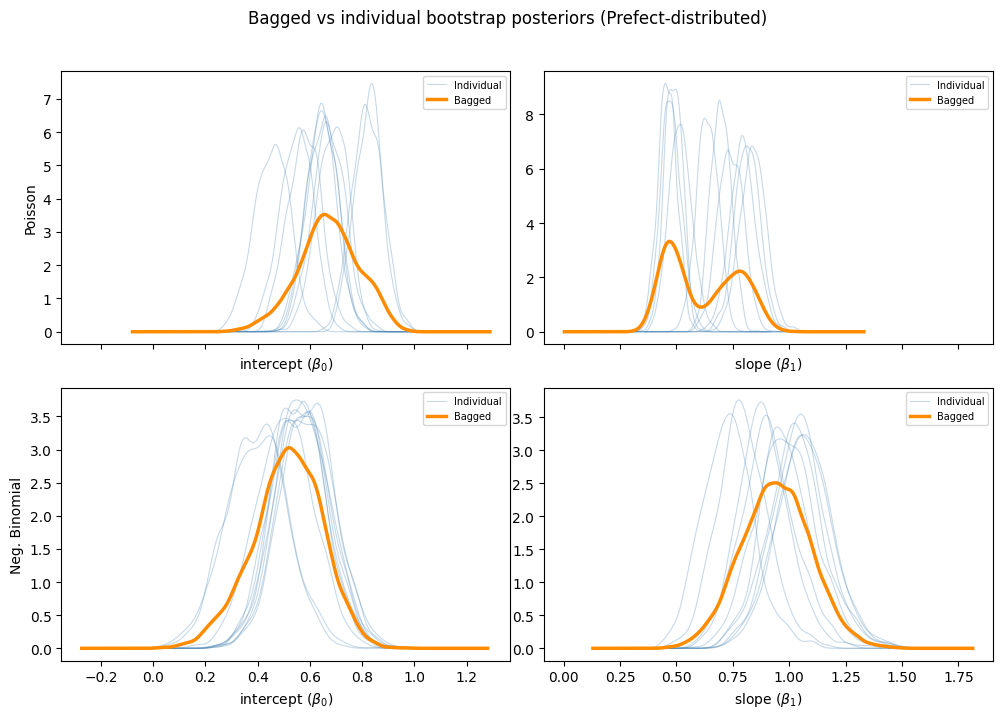

In [7]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex='col')

for row, (bagged, label) in enumerate([(bagged_poisson_pf, 'Poisson'),
                                        (bagged_nb_pf, 'Neg. Binomial')]):
    for col, name in enumerate(['intercept', 'slope']):
        param_label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
        ax = axes[row, col]
        for i, post in enumerate(bagged.components[:10]):
            d = np.asarray(post.draws()[name])
            xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
            ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color='steelblue',
                    label='Individual' if i == 0 else None)
        bd = np.concatenate([np.asarray(p.draws()[name]) for p in bagged.components])
        xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(bd)(xs), color='darkorange', lw=2.5, label='Bagged')
        ax.set(xlabel=param_label); ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label)

plt.suptitle('Bagged vs individual bootstrap posteriors (Prefect-distributed)', y=1.02)
plt.tight_layout(); plt.show()

## 7. Global off switch and per-instance override

The global config can be changed at any time. Here we demonstrate turning Prefect off globally, and overriding per-instance.

In [8]:
# Turn Prefect off globally
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF
print(f"Global config: {probpipe.prefect_config.workflow_kind}")

# A WorkflowFunction with DEFAULT inherits the global setting
from probpipe.core.node import WorkflowFunction

def add_one(x):
    return x + 1.0

wf_default = WorkflowFunction(func=add_one, seed=0)
print(f"DEFAULT instance resolves to: {wf_default.effective_workflow_kind}")

# A per-instance TASK override still uses Prefect
wf_task = WorkflowFunction(func=add_one, workflow_kind=WorkflowKind.TASK, seed=0)
print(f"Explicit TASK instance resolves to: {wf_task.effective_workflow_kind}")

# Show what DEFAULT resolves to when global is DEFAULT (auto-detect)
probpipe.prefect_config.reset()
print(f"\nAfter reset, global is: {probpipe.prefect_config.workflow_kind}")
print(f"DEFAULT instance now resolves to: {wf_default.effective_workflow_kind}")

# Set back to OFF since we don't have a running Prefect server
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

Global config: WorkflowKind.OFF
DEFAULT instance resolves to: WorkflowKind.OFF
Explicit TASK instance resolves to: WorkflowKind.TASK

After reset, global is: WorkflowKind.DEFAULT
DEFAULT instance now resolves to: WorkflowKind.TASK


## 8. Task runner configuration

For true parallelism (beyond Prefect's in-process default), ProbPipe auto-detects installed runner packages. If `prefect-ray` is installed, `RayTaskRunner` is used automatically. You can also set it explicitly for remote clusters:

```python
from prefect_ray import RayTaskRunner

# Auto-detected (if prefect-ray is installed):
print(probpipe.prefect_config.resolve_task_runner())

# Explicit remote cluster:
probpipe.prefect_config.task_runner = RayTaskRunner(address="ray://cluster:10001")
```

Auto-detection priority: **Ray > Dask > Prefect default**.

In [9]:
# Show what task runner is currently auto-detected
runner = probpipe.prefect_config.resolve_task_runner()
print(f"Auto-detected task runner: {runner}")
print(f"Explicit task runner: {probpipe.prefect_config.task_runner}")

Auto-detected task runner: None
Explicit task runner: None
